# Exercise 12.6 — Q1: Fruit Basket Random Forest

**Lab Book §12.6 Exercise 1 (page 58):**  
> Consider the fruit basket as the data as shown in the figure below.
> Now n number of samples are taken from the fruit basket, and an
> individual decision tree is constructed for each sample. Each decision
> tree will generate an output, as shown in the figure. Which fruit is
> likely to be taken often?

**Course:** 23CSE301 — Machine Learning Lab  
**Topic:** Random Forest Ensemble — synthetic fruit-basket dataset  
**Dataset:** `datasets/fruit_basket.csv` (200 rows × 5 cols: `color`,
`size_cm`, `weight_g`, `sweetness`, `fruit`).

---

## 🎯 Objective

Build a Random Forest classifier on a synthetic fruit dataset.  The
forest trains many bootstrap-sampled decision trees, each voting on the
final fruit class.  We then look at the per-tree predictions for a
sample fruit to see "which fruit is likely to be taken often" by the
ensemble.

## 📁 Files in this Folder

| File | Description |
|------|-------------|
| `08_Q1_Fruit_Basket.ipynb` | This notebook |
| `datasets/fruit_basket.csv` | 200-row synthetic fruit dataset |


In [1]:
# === Environment setup (works in both Google Colab and local Jupyter) ===
import os, sys

IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/ML-Lab-Activities-Complete'
    os.chdir(os.path.join(BASE, '08-Random-Forest'))
    print(f'Running in Google Colab. CWD: {os.getcwd()}')
else:
    print(f'Running locally. CWD: {os.getcwd()}')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_DIR, exist_ok=True)
_PREFIX = 'Q1_Fruit_Basket_'

# Patch plt.show so every figure is also auto-saved as PNG (with prefix to
# avoid collisions between multiple notebooks sharing the same outputs/ dir)
import matplotlib.pyplot as plt
_fig_counter = [0]
_orig_plt_show = plt.show
def _save_and_show(*args, **kwargs):
    for fnum in plt.get_fignums():
        _fig_counter[0] += 1
        fig = plt.figure(fnum)
        fname = f'{_PREFIX}figure_{_fig_counter[0]:03d}.png'
        try:
            fig.savefig(os.path.join(OUTPUT_DIR, fname), dpi=120, bbox_inches='tight')
        except Exception as e:
            print(f'Warning: could not save {fname}: {e}')
    _orig_plt_show(*args, **kwargs)
plt.show = _save_and_show

print('Setup complete. Figures will be auto-saved to:', OUTPUT_DIR)


Running locally. CWD: /home/z/my-project/work/build/ML-Lab-Activities/08-Random-Forest


Setup complete. Figures will be auto-saved to: /home/z/my-project/work/build/ML-Lab-Activities/08-Random-Forest/outputs


## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import (confusion_matrix, accuracy_score,
                             classification_report)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Libraries imported.')

Libraries imported.


## 2. Load Dataset

In [3]:
df = pd.read_csv('datasets/fruit_basket.csv')
print(f"Shape: {df.shape}")
display(df.head(10))
print("\nClass distribution:")
print(df['fruit'].value_counts())

Shape: (200, 5)


,color,size_cm,weight_g,sweetness,fruit
0,purple,19.25,402.92,4.30,Orange
1,violet,9.98,268.20,1.70,Plum
2,indigo,22.58,495.30,10.46,Orange
3,violet,16.06,357.90,7.52,Plum
4,indigo,5.77,170.12,1.11,Grape
5,violet,6.16,159.51,1.30,Plum
6,indigo,18.25,617.36,3.75,Orange
7,purple,6.80,168.55,-0.82,Plum
8,violet,14.16,437.44,4.07,Plum
9,purple,24.82,668.07,5.95,Orange



Class distribution:
fruit
Orange    90
Plum      63
Grape     27
Apple     20
Name: count, dtype: int64


## 3. Encode Categorical Features

In [4]:
df_enc = df.copy()
color_le = LabelEncoder()
fruit_le = LabelEncoder()
df_enc['color'] = color_le.fit_transform(df['color'])
df_enc['fruit'] = fruit_le.fit_transform(df['fruit'])

print("Color mapping:", dict(zip(color_le.classes_,
                                  color_le.transform(color_le.classes_))))
print("Fruit mapping:", dict(zip(fruit_le.classes_,
                                  fruit_le.transform(fruit_le.classes_))))

Color mapping: {'indigo': np.int64(0), 'purple': np.int64(1), 'violet': np.int64(2)}
Fruit mapping: {'Apple': np.int64(0), 'Grape': np.int64(1), 'Orange': np.int64(2), 'Plum': np.int64(3)}


## 4. Define Features & Target

In [5]:
X = df_enc[['color', 'size_cm', 'weight_g', 'sweetness']]
y = df_enc['fruit']
print(f"X shape: {X.shape}, y shape: {y.shape}")

X shape: (200, 4), y shape: (200,)


## 5. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (140, 4), Test: (60, 4)


## 6. Train Random Forest (10 trees, entropy)

In [7]:
model = RandomForestClassifier(n_estimators=10, criterion='entropy',
                                random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=fruit_le.classes_))

Accuracy: 0.6667

Classification Report:
              precision    recall  f1-score   support

       Apple       0.20      0.17      0.18         6
       Grape       0.75      0.38      0.50         8
      Orange       0.66      0.85      0.74        27
        Plum       0.81      0.68      0.74        19

    accuracy                           0.67        60
   macro avg       0.60      0.52      0.54        60
weighted avg       0.67      0.67      0.65        60



## 7. Confusion Matrix

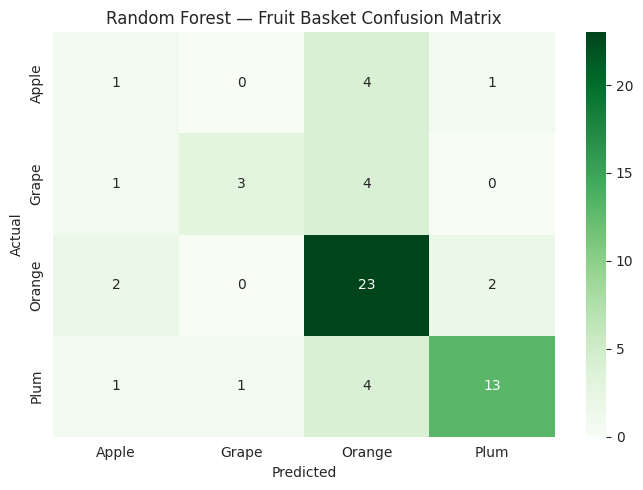

In [8]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=fruit_le.classes_,
            yticklabels=fruit_le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Random Forest — Fruit Basket Confusion Matrix')
plt.tight_layout()
plt.show()

## 8. Visualise One Tree from the Forest

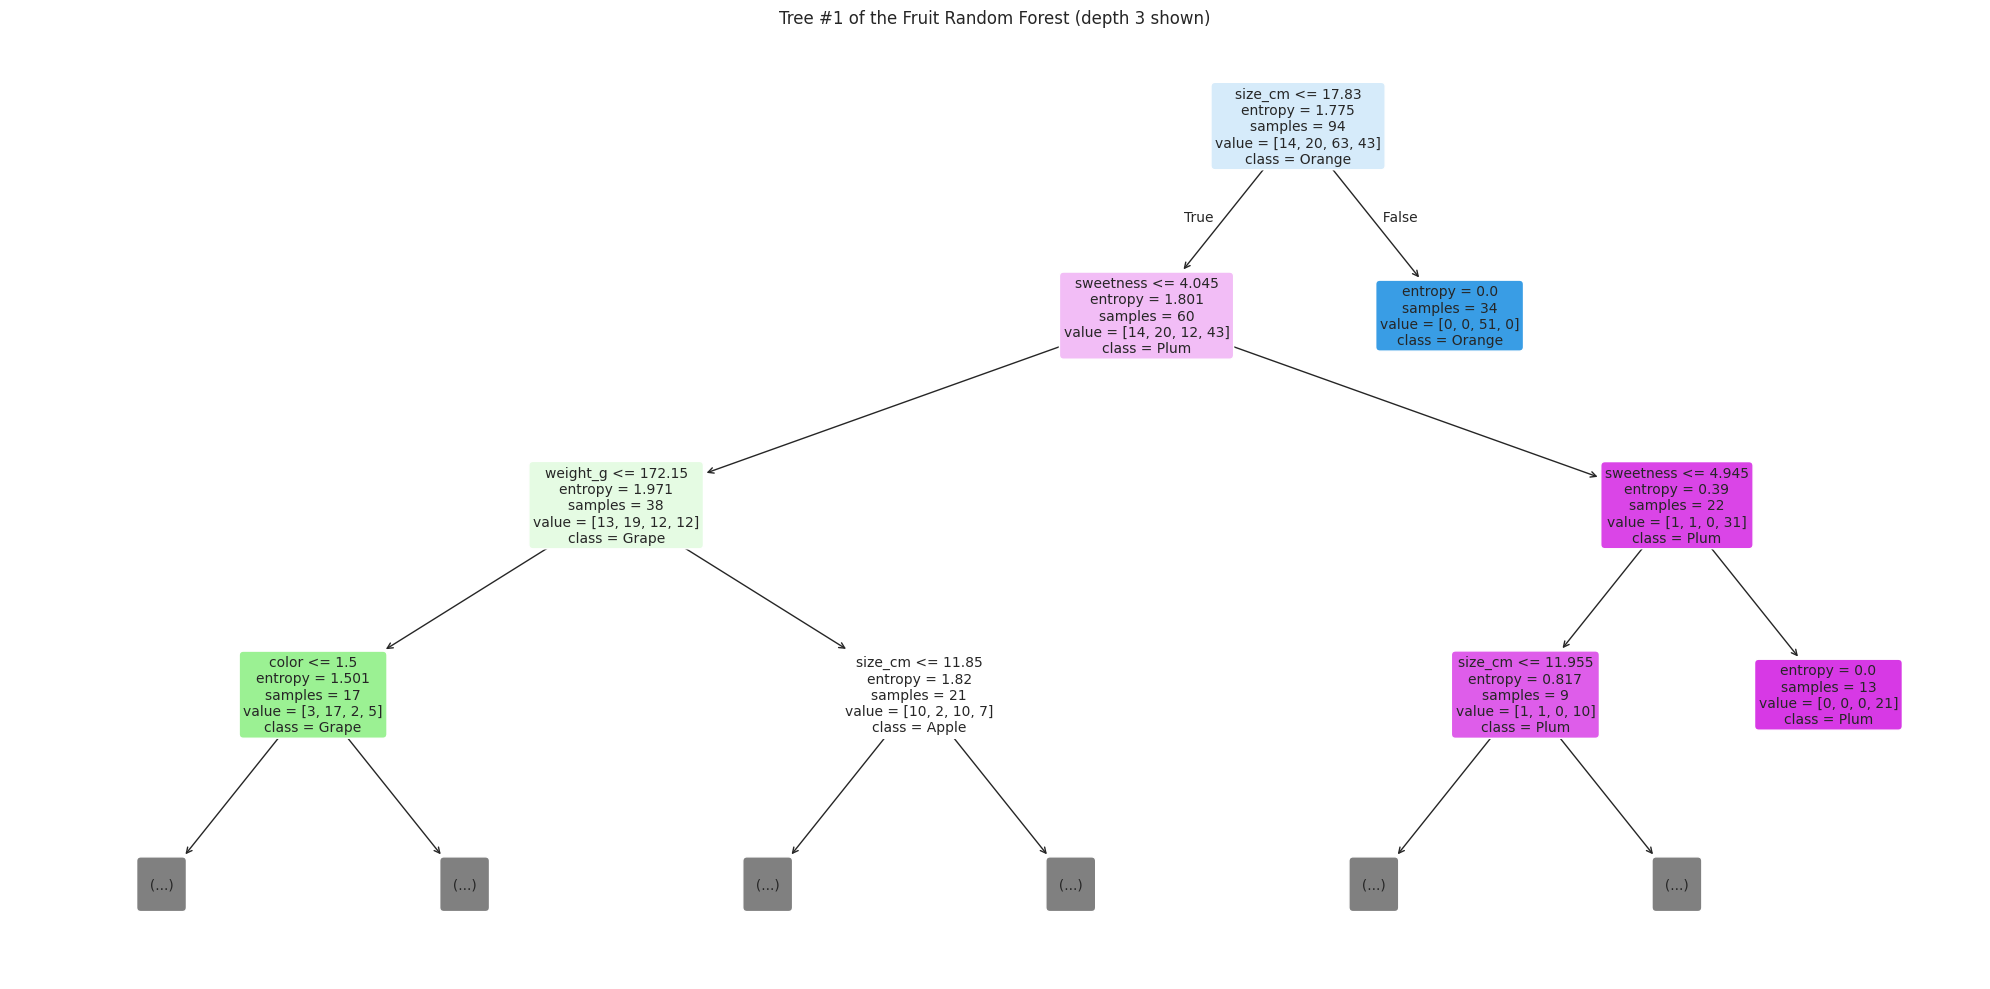

In [9]:
plt.figure(figsize=(20, 10))
plot_tree(model.estimators_[0],
          feature_names=X.columns.tolist(),
          class_names=fruit_le.classes_,
          filled=True, rounded=True, fontsize=10, max_depth=3)
plt.title('Tree #1 of the Fruit Random Forest (depth 3 shown)')
plt.tight_layout()
plt.show()

## 9. Feature Importance

,Feature,Importance
1,size_cm,0.601905
2,weight_g,0.233858
3,sweetness,0.118862
0,color,0.045375


/tmp/ipykernel_4565/4078419516.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')


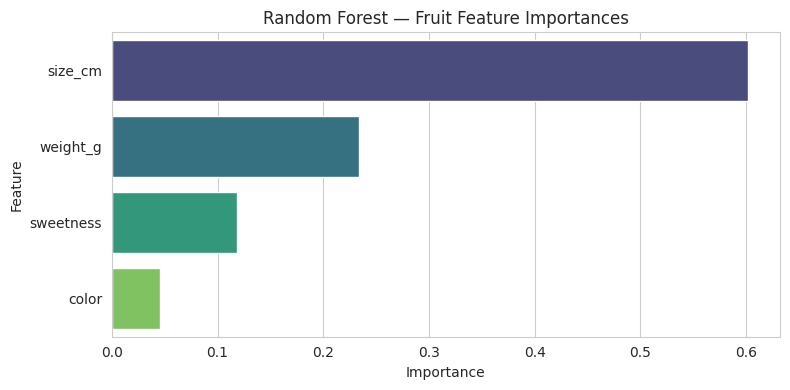

In [10]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_,
}).sort_values('Importance', ascending=False)
display(importance)

plt.figure(figsize=(8, 4))
sns.barplot(x='Importance', y='Feature', data=importance, palette='viridis')
plt.title('Random Forest — Fruit Feature Importances')
plt.tight_layout()
plt.show()

## 10. "Which fruit is likely to be taken often?"

For a given test fruit, each of the 10 trees produces a vote. The
majority vote is the final Random Forest prediction. Let's inspect
the votes for one test sample to see how individual trees voted.

In [11]:
sample_idx = 0
sample = X_test.iloc[[sample_idx]]
print(f"Sample #{sample_idx} features:")
display(X_test.iloc[[sample_idx]])
print(f"\nTrue class: {fruit_le.classes_[y_test.iloc[sample_idx]]}")

votes = []
for i, tree in enumerate(model.estimators_):
    v = int(tree.predict(sample)[0])
    votes.append(v)
    print(f"  Tree {i+1:2d} voted: {fruit_le.classes_[v]}")

from collections import Counter
vote_counts = Counter(votes)
print("\nVote tally:")
for cls_int, count in vote_counts.most_common():
    print(f"  {fruit_le.classes_[cls_int]}: {count} votes")
print(f"\nFinal RF prediction (majority vote): {fruit_le.classes_[int(model.predict(sample)[0])]}")

Sample #0 features:


,color,size_cm,weight_g,sweetness
161,1,12.56,374.09,5.22



True class: Plum
  Tree  1 voted: Plum
  Tree  2 voted: Plum
  Tree  3 voted: Plum
  Tree  4 voted: Plum
  Tree  5 voted: Plum
  Tree  6 voted: Plum
  Tree  7 voted: Plum
  Tree  8 voted: Plum
  Tree  9 voted: Plum
  Tree 10 voted: Plum

Vote tally:
  Plum: 10 votes

Final RF prediction (majority vote): Plum


/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/home/z/.venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but DecisionTreeClassifier 

## 📚 Key Takeaways
- Random Forest combines many bootstrap-sampled decision trees via
  **majority voting**.
- Each tree's vote can be inspected — when most trees agree on a class,
  that class becomes the final prediction.
- **"Which fruit is likely to be taken often?"** = the fruit that
  receives the most votes across the ensemble's trees.
- Feature importance reveals which features (typically `size_cm` and
  `color`) drive the classification.
